# Comparação Visual de Profundidade
**Projeto:** Aprimoramento de SLAM Monocular — UFBA PPGEE0028

Compara os mapas de profundidade gerados por cada pipeline para um mesmo frame RGB:
- Kinect (groundtruth)
- MiDaS puro (disparidade relativa)
- MiDaS + Calibração 
- DAV2 Métrico


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os


# CONFIGURAÇÕES — ajuste o dataset aqui
DATASET = 'fr3_office'  # 'fr2_xyz' | 'fr1_desk' | 'fr3_office'

DATASET_DIRS = {
    'fr2_xyz':   '/home/rafael/datasets/tum/rgbd_dataset_freiburg2_xyz',
    'fr1_desk':  '/home/rafael/datasets/tum/rgbd_dataset_freiburg1_desk',
    'fr3_office': '/home/rafael/datasets/tum/rgbd_dataset_freiburg3_long_office_household',
}
DEPTH_FACTOR_REAL = {'fr2_xyz': 5208.0, 'fr1_desk': 5000.0, 'fr3_office': 5000.0}

BASE     = DATASET_DIRS[DATASET]
DF_REAL  = DEPTH_FACTOR_REAL[DATASET]
DF_SINT  = 5000.0

print(f'Dataset : {DATASET}')
print(f'Base    : {BASE}')
print(f'DF real : {DF_REAL}')


Dataset : fr3_office
Base    : /home/rafael/datasets/tum/rgbd_dataset_freiburg3_long_office_household
DF real : 5000.0


In [ ]:
#  Encontrar frames comuns e escolher um
def listar_ts(pasta):
    if not os.path.exists(pasta):
        print(f'  [AVISO] pasta não encontrada: {pasta}')
        return set()
    return set(f[:-4] for f in os.listdir(pasta) if f.endswith('.png'))

pastas = {
    'depth_real':  f'{BASE}/depth',
    'depth_midas': f'{BASE}/depth_midas',
    'depth_affin': f'{BASE}/depth_midas_affine',
    'depth_dav2':  f'{BASE}/depth_dav2_metric_vitl',
    'rgb':         f'{BASE}/rgb',
}

print('Frames disponíveis por pasta:')
sets = {}
for nome, pasta in pastas.items():
    s = listar_ts(pasta)
    sets[nome] = s
    print(f'  {nome:<16}: {len(s)} frames')

comuns = sorted(set.intersection(*[s for s in sets.values() if s]))
print(f'\nFrames comuns: {len(comuns)}')

# Índice do frame a visualizar (0=início, meio, fim ou qualquer índice)
IDX_FRAME = len(comuns) // 2
TS = comuns[IDX_FRAME]
print(f'Frame escolhido (idx={IDX_FRAME}): {TS}')


Frames disponíveis por pasta:
  depth_real      : 2509 frames
  depth_midas     : 2585 frames
  depth_affin     : 2585 frames
  depth_dav2      : 2585 frames
  rgb             : 2585 frames

Frames comuns: 2
Frame escolhido (idx=1): 1341848005.025661


In [ ]:
# Carregar imagens do frame escolhido
def carregar(pasta, ts, fator=1.0):
    path = os.path.join(pasta, ts + '.png')
    if not os.path.exists(path):
        print(f'  [AVISO] não encontrado: {path}')
        return None
    img = np.array(Image.open(path))
    if fator != 1.0:
        img = img.astype(np.float32) / fator
    return img

rgb     = carregar(pastas['rgb'],         TS)
d_real  = carregar(pastas['depth_real'],  TS, DF_REAL)
d_midas = carregar(pastas['depth_midas'], TS, DF_SINT)
d_affin = carregar(pastas['depth_affin'], TS, DF_SINT)
d_dav2  = carregar(pastas['depth_dav2'],  TS, DF_SINT)

# Estatísticas
mask = d_real > 0.1
print(f'{'Canal':<20} {'Mean(m)':>8} {'Max(m)':>8} {'Pixels válidos':>16}')
print('-' * 58)
for nome, d in [('Kinect (GT)', d_real), ('MiDaS puro', d_midas),
                ('MiDaS + Affine', d_affin), ('DAV2 Métrico', d_dav2)]:
    m = d > 0.1
    print(f'{nome:<20} {d[m].mean():>8.2f} {d[m].max():>8.2f} {m.sum():>16}')


Canal                 Mean(m)   Max(m)   Pixels válidos
----------------------------------------------------------
Kinect (GT)              1.63     6.89           265125
MiDaS puro               6.92    13.11           306593
MiDaS + Affine           1.82     3.44           307200
DAV2 Métrico             1.68     5.98           307200


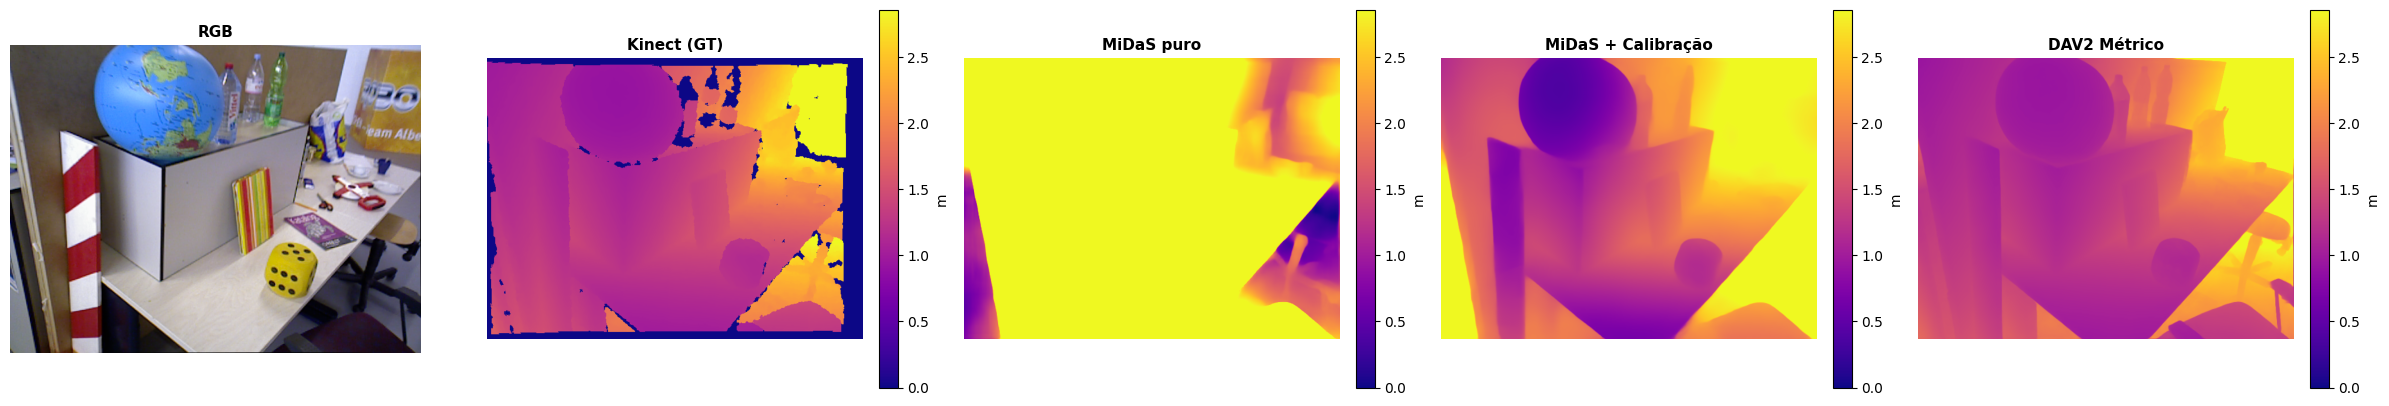

Figura 1×5 salva!


In [ ]:
# Comparação 1×5 (RGB + 4 depth maps)
mask   = d_real > 0.1
vmax   = np.percentile(d_real[mask], 95)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
#fig.suptitle(f'Comparação de Profundidade — {DATASET}  (frame {TS[:13]})',
 #            fontsize=13, fontweight='bold')

dados = [
    (rgb,     'RGB',                None,     None),
    (d_real,  'Kinect (GT)',        'plasma', vmax),
    (d_midas, 'MiDaS puro',        'plasma', vmax),
    (d_affin, 'MiDaS + Calibração',    'plasma', vmax),
    (d_dav2,  'DAV2 Métrico',      'plasma', vmax),
]

for ax, (img, titulo, cmap, vm) in zip(axes, dados):
    if cmap:
        im = ax.imshow(img, cmap=cmap, vmin=0, vmax=vm)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='m')
    else:
        ax.imshow(img)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


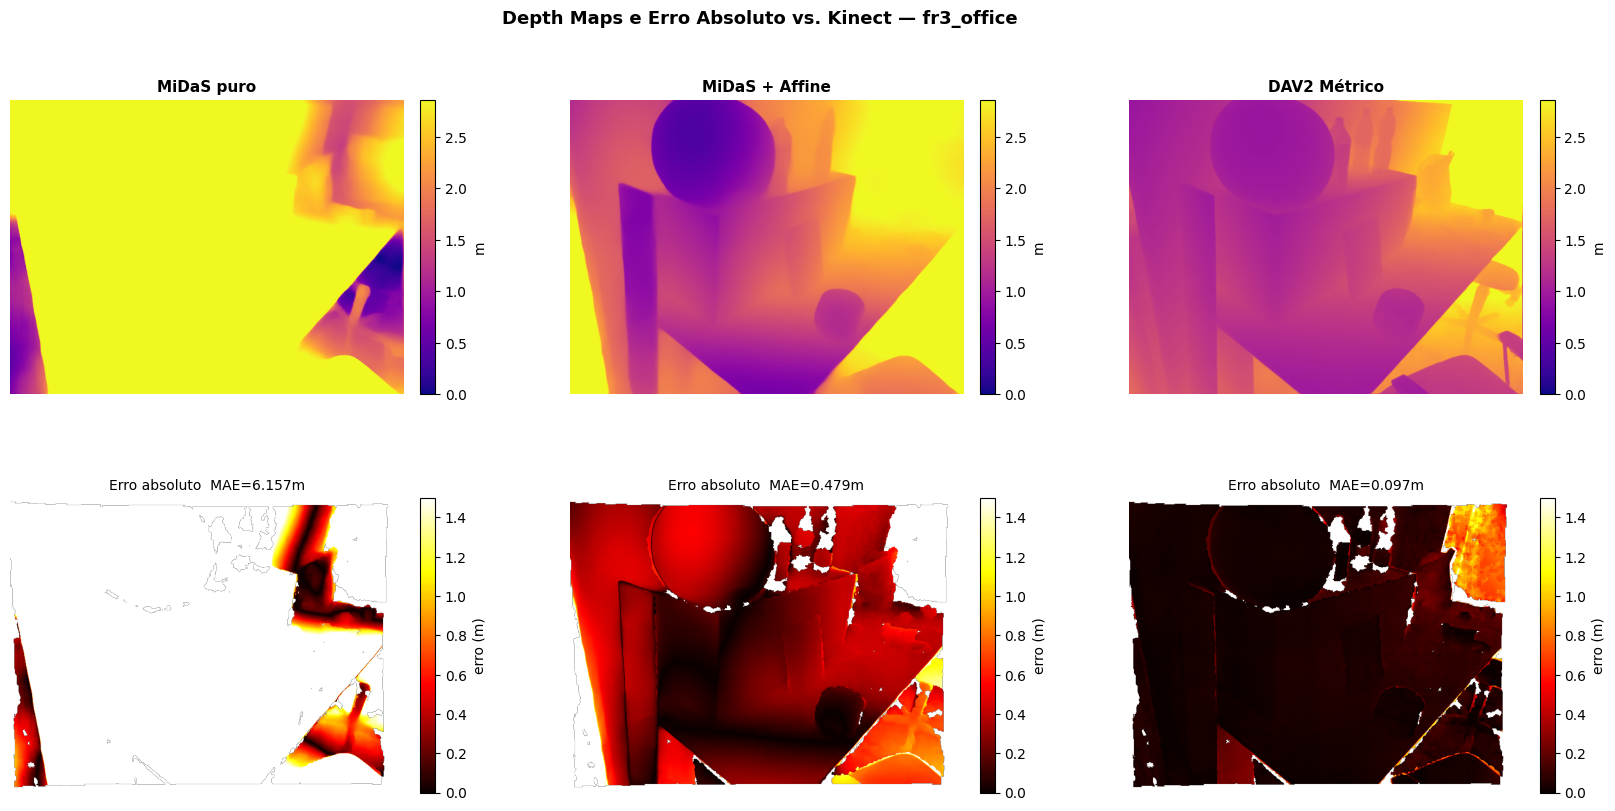

Figura 2×3 com erro salva!


In [ ]:
# Painel 2×3: depth maps + mapa de erro vs Kinect
mask = (d_real > 0.1) & (d_real < 8.0)
vmax = np.percentile(d_real[mask], 95)
emax = 1.5  # metros — clamp do erro

fig = plt.figure(figsize=(20, 9))
fig.suptitle(f'Depth Maps e Erro Absoluto vs. Kinect — {DATASET}',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

pipelines = [
    (d_midas, 'MiDaS puro'),
    (d_affin, 'MiDaS + Affine'),
    (d_dav2,  'DAV2 Métrico'),
]

for col, (d, titulo) in enumerate(pipelines):
    # Linha 0 — depth map
    ax_d = fig.add_subplot(gs[0, col])
    im = ax_d.imshow(d, cmap='plasma', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax_d, fraction=0.046, pad=0.04, label='m')
    ax_d.set_title(titulo, fontsize=11, fontweight='bold')
    ax_d.axis('off')

    # Linha 1 — erro absoluto
    ax_e = fig.add_subplot(gs[1, col])
    erro = np.where(mask, np.abs(d - d_real), np.nan)
    im_e = ax_e.imshow(erro, cmap='hot', vmin=0, vmax=emax)
    plt.colorbar(im_e, ax=ax_e, fraction=0.046, pad=0.04, label='erro (m)')
    mae = np.nanmean(erro)
    ax_e.set_title(f'Erro absoluto  MAE={mae:.3f}m', fontsize=10)
    ax_e.axis('off')

plt.show()
